# [SM-TCSR 실습 03] C51 손실 불일치 극복: Cramér Loss vs Cross-Entropy

> **학습 목표**: 
> 1. 범주형 교차 엔트로피(Cross-Entropy)의 "서열 무지성(Ordinal Blindness)"을 실증합니다.
> 2. 누적분포함수(CDF) 기반 $L_2$ Cramér Loss가 어떻게 시간 축의 기하학적 거리를 완벽히 반영하는지 확인합니다.


In [1]:
import sys, os
ROOT_DIR = os.path.abspath("..")
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

import torch
import numpy as np
import matplotlib.pyplot as plt

K = 30
delta_s = 1.0

# 참값 타깃: 5번째 빈에 집중된 디락 분포 (사망 5시간 뒤)
target_pmf = torch.zeros(K)
target_pmf[5] = 1.0
target_cdf = torch.cumsum(target_pmf, dim=-1)

# 예측 분포의 중심을 6번째 빈부터 28번째 빈까지 이동시키며 오차 측정
shifts = list(range(6, 28))
ce_losses = []
cramer_losses = []

for s in shifts:
    pred_pmf = torch.zeros(K)
    pred_pmf[s] = 1.0
    pred_cdf = torch.cumsum(pred_pmf, dim=-1)
    
    # 1. Categorical Cross Entropy: - sum(target * log(pred + eps))
    ce = -torch.sum(target_pmf * torch.log(pred_pmf.clamp_min(1e-6))).item()
    ce_losses.append(ce)
    
    # 2. L2 Cramér Distance Loss: delta_s * sum((F_pred - F_target)^2)
    cramer = (delta_s * torch.sum((pred_cdf - target_cdf) ** 2)).item()
    cramer_losses.append(cramer)

print("시뮬레이션 완료!")


시뮬레이션 완료!


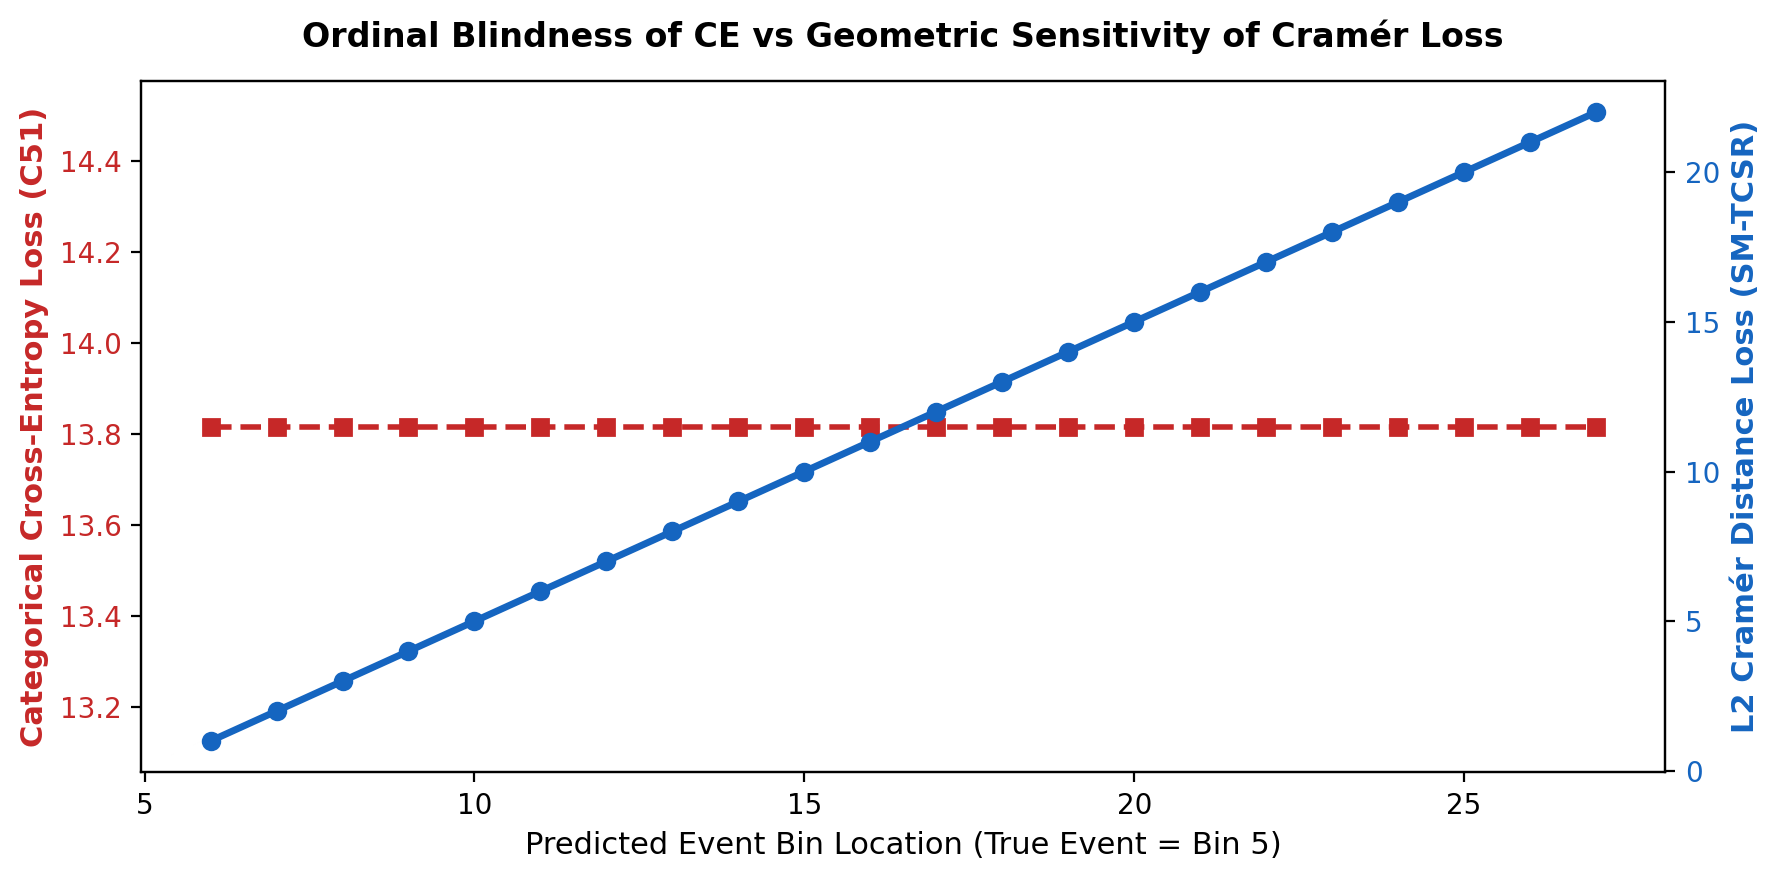

In [2]:
# 시각화 비교
fig, ax1 = plt.subplots(figsize=(9, 4.5), dpi=200)

color = '#c62828'
ax1.set_xlabel('Predicted Event Bin Location (True Event = Bin 5)', fontsize=11)
ax1.set_ylabel('Categorical Cross-Entropy Loss (C51)', color=color, fontsize=11, fontweight='bold')
ax1.plot(shifts, ce_losses, 's--', color=color, lw=2, label='Cross-Entropy (Ordinal Blind)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#1565c0'
ax2.set_ylabel('L2 Cramér Distance Loss (SM-TCSR)', color=color, fontsize=11, fontweight='bold')
ax2.plot(shifts, cramer_losses, 'o-', color=color, lw=2.5, label='Cramér Distance (Metric-Preserving)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Ordinal Blindness of CE vs Geometric Sensitivity of Cramér Loss", fontsize=12, fontweight='bold', pad=12)
fig.tight_layout()
plt.show()
